In [20]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

# print("Path to dataset files:", "/media/radii/New Volume/Instant Ai Advance/lec proj/Classification ofLung Diseases/lung-disease-classification/data/raw")

In [21]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset")

# print("Path to dataset files:", path)

In [22]:
from pathlib import Path

BASE_DIR = Path("..") / "data" / "raw"

covid_dir = BASE_DIR / "COVID-19_Radiography_Dataset" / "COVID" / "images"
normal_dir = BASE_DIR / "COVID-19_Radiography_Dataset" / "Normal" / "images"
tb_dir = BASE_DIR / "TB_Chest_Radiography_Database" / "Tuberculosis"

In [23]:
for name, path in {
    "COVID": covid_dir,
    "Normal": normal_dir,
    "Tuberculosis": tb_dir
}.items():
    files = list(path.glob("*"))
    print(f"{name}: {len(files)} files")

COVID: 3616 files
Normal: 10192 files
Tuberculosis: 700 files


In [24]:
IMG_EXTENSIONS = {".png", ".jpg", ".jpeg"}

def get_images(folder):
    return [
        file for file in folder.iterdir()
        if file.suffix.lower() in IMG_EXTENSIONS
    ]

covid_images = get_images(covid_dir)
normal_images = get_images(normal_dir)
tb_images = get_images(tb_dir)

print("COVID:", len(covid_images))
print("Normal:", len(normal_images))
print("Tuberculosis:", len(tb_images))

COVID: 3616
Normal: 10192
Tuberculosis: 700


In [25]:
import random

random.seed(42)

SAMPLES_PER_CLASS = 700

covid_sample = random.sample(covid_images, SAMPLES_PER_CLASS)
normal_sample = random.sample(normal_images, SAMPLES_PER_CLASS)
tb_sample = random.sample(tb_images, SAMPLES_PER_CLASS)

print("COVID:", len(covid_sample))
print("Normal:", len(normal_sample))
print("Tuberculosis:", len(tb_sample))

COVID: 700
Normal: 700
Tuberculosis: 700


In [26]:
import cv2
import numpy as np

IMG_SIZE = (100, 100)

def preprocess_images(image_paths, label):
    X = []
    y = []

    for img_path in image_paths:
        img = cv2.imread(str(img_path))

        if img is None:
            print(f"Could not read: {img_path}")
            continue

        img = cv2.resize(img, IMG_SIZE)

        X.append(img)
        y.append(label)

    return X, y

In [27]:
X_normal, y_normal = preprocess_images(normal_sample, 0)
X_covid, y_covid = preprocess_images(covid_sample, 1)
X_tb, y_tb = preprocess_images(tb_sample, 2)

In [28]:
X = np.array(X_normal + X_covid + X_tb)
y = np.array(y_normal + y_covid + y_tb)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2100, 100, 100, 3)
y shape: (2100,)


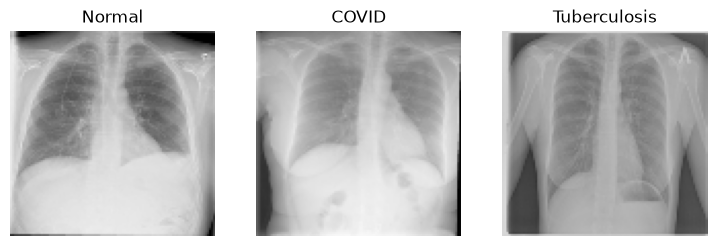

In [29]:
import matplotlib.pyplot as plt

class_names = {
    0: "Normal",
    1: "COVID",
    2: "Tuberculosis"
}

plt.figure(figsize=(9, 3))

for i, label in enumerate([0, 1, 2]):
    index = np.where(y == label)[0][0]

    plt.subplot(1, 3, i + 1)
    plt.imshow(cv2.cvtColor(X[index], cv2.COLOR_BGR2RGB))
    plt.title(class_names[label])
    plt.axis("off")

plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1680, 100, 100, 3)
X_test: (420, 100, 100, 3)
y_train: (1680,)
y_test: (420,)


In [31]:
import pandas as pd

print("Training distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training distribution:
0    560
1    560
2    560
Name: count, dtype: int64

Testing distribution:
0    140
1    140
2    140
Name: count, dtype: int64


In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=40,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

I0000 00:00:1790593314.222266    8905 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790593314.222785    8905 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790593314.261722    8905 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790593315.255813    8905 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

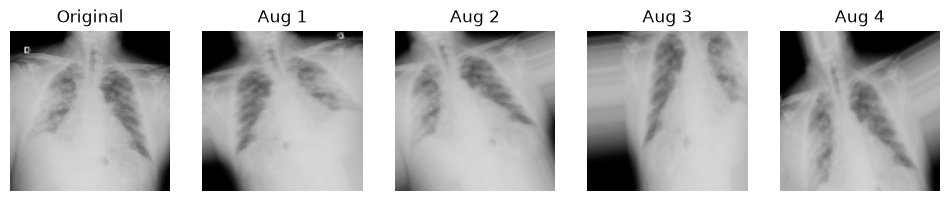

In [33]:
sample_image = X_train[0]

generator = datagen.flow(
    np.expand_dims(sample_image, axis=0),
    batch_size=1
)

plt.figure(figsize=(12, 3))

plt.subplot(1, 5, 1)
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

for i in range(4):
    augmented = next(generator)[0].astype(np.uint8)

    plt.subplot(1, 5, i + 2)
    plt.imshow(cv2.cvtColor(augmented, cv2.COLOR_BGR2RGB))
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.show()

In [34]:
augmented_images = []
augmented_labels = []

for image, label in zip(X_train, y_train):

    generator = datagen.flow(
        np.expand_dims(image, axis=0),
        batch_size=1
    )

    augmented_image = next(generator)[0].astype(np.uint8)

    augmented_images.append(augmented_image)
    augmented_labels.append(label)

In [35]:
X_train_aug = np.concatenate(
    [X_train, np.array(augmented_images)],
    axis=0
)

y_train_aug = np.concatenate(
    [y_train, np.array(augmented_labels)],
    axis=0
)

print("Before augmentation:", X_train.shape)
print("After augmentation:", X_train_aug.shape)

Before augmentation: (1680, 100, 100, 3)
After augmentation: (3360, 100, 100, 3)


In [36]:
X_train_flat = X_train_aug.reshape(X_train_aug.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Train before flatten:", X_train_aug.shape)
print("Train after flatten:", X_train_flat.shape)

print("Test before flatten:", X_test.shape)
print("Test after flatten:", X_test_flat.shape)

Train before flatten: (3360, 100, 100, 3)
Train after flatten: (3360, 30000)
Test before flatten: (420, 100, 100, 3)
Test after flatten: (420, 30000)


In [38]:
X_train_scaled = X_train_flat.astype("float32") / 255.0
X_test_scaled = X_test_flat.astype("float32") / 255.0

print("Min:", X_train_scaled.min())
print("Max:", X_train_scaled.max())

Min: 0.0
Max: 1.0


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

results = []

def evaluate_model(name, model, X_test_data, y_test):
    
    y_pred = model.predict(X_test_data)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"\n{name}")
    print("-" * 40)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Normal",
                "COVID",
                "Tuberculosis"
            ]
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=[
            "Normal",
            "COVID",
            "Tuberculosis"
        ],
        cmap="Blues"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [43]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

extra_trees.fit(
    X_train_flat,
    y_train_aug
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impuri


Extra Trees
----------------------------------------
Accuracy : 0.8857
Precision: 0.89
Recall   : 0.8857
F1 Score : 0.8857

Classification Report:

              precision    recall  f1-score   support

      Normal       0.82      0.93      0.87       140
       COVID       0.90      0.81      0.85       140
Tuberculosis       0.95      0.92      0.93       140

    accuracy                           0.89       420
   macro avg       0.89      0.89      0.89       420
weighted avg       0.89      0.89      0.89       420



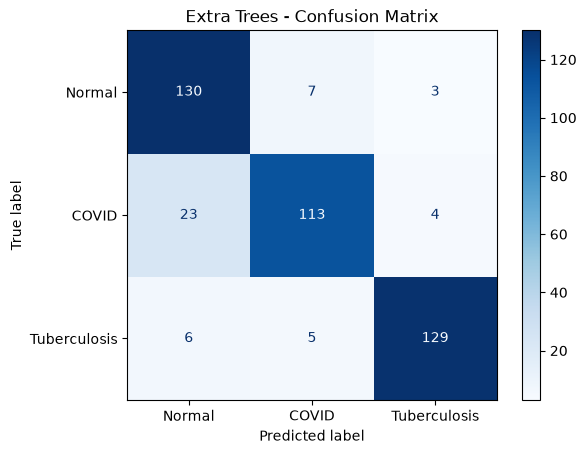

In [46]:
evaluate_model(
    "Extra Trees",
    extra_trees,
    X_test_flat,
    y_test
)

In [47]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_flat,
    y_train_aug
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total


Random Forest
----------------------------------------
Accuracy : 0.881
Precision: 0.8865
Recall   : 0.881
F1 Score : 0.8808

Classification Report:

              precision    recall  f1-score   support

      Normal       0.81      0.93      0.86       140
       COVID       0.92      0.79      0.85       140
Tuberculosis       0.93      0.92      0.93       140

    accuracy                           0.88       420
   macro avg       0.89      0.88      0.88       420
weighted avg       0.89      0.88      0.88       420



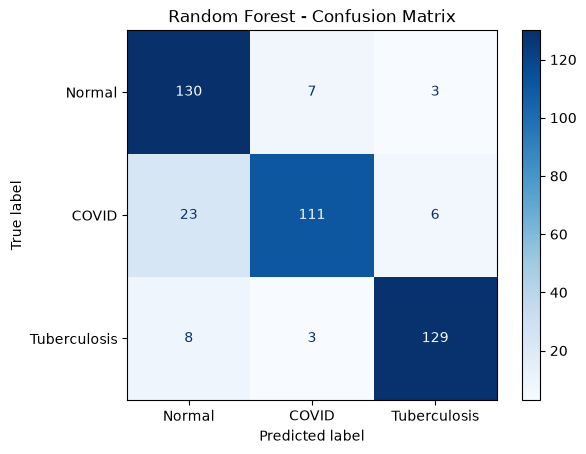

In [48]:
evaluate_model(
    "Random Forest",
    random_forest,
    X_test_flat,
    y_test
)

In [49]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=3,
    n_jobs=-1
)

knn.fit(
    X_train_scaled,
    y_train_aug
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'



KNN
----------------------------------------
Accuracy : 0.8048
Precision: 0.8141
Recall   : 0.8048
F1 Score : 0.8061

Classification Report:

              precision    recall  f1-score   support

      Normal       0.75      0.84      0.79       140
       COVID       0.77      0.80      0.79       140
Tuberculosis       0.92      0.77      0.84       140

    accuracy                           0.80       420
   macro avg       0.81      0.80      0.81       420
weighted avg       0.81      0.80      0.81       420



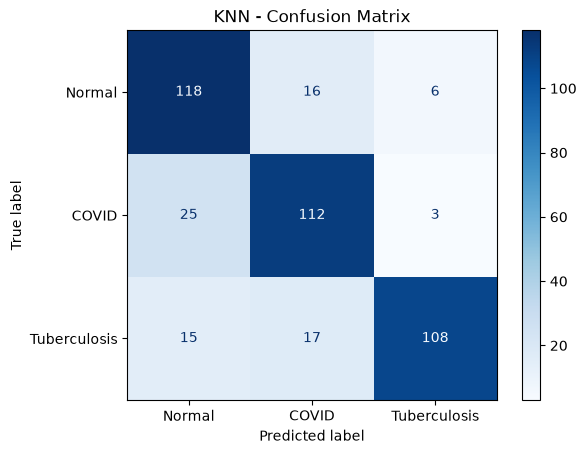

In [50]:
evaluate_model(
    "KNN",
    knn,
    X_test_scaled,
    y_test
)

In [51]:
from sklearn.svm import SVC

svm = SVC(
    kernel="linear",
    random_state=42
)

svm.fit(
    X_train_scaled,
    y_train_aug
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None



SVM
----------------------------------------
Accuracy : 0.7476
Precision: 0.7516
Recall   : 0.7476
F1 Score : 0.7488

Classification Report:

              precision    recall  f1-score   support

      Normal       0.63      0.69      0.66       140
       COVID       0.72      0.67      0.70       140
Tuberculosis       0.90      0.88      0.89       140

    accuracy                           0.75       420
   macro avg       0.75      0.75      0.75       420
weighted avg       0.75      0.75      0.75       420



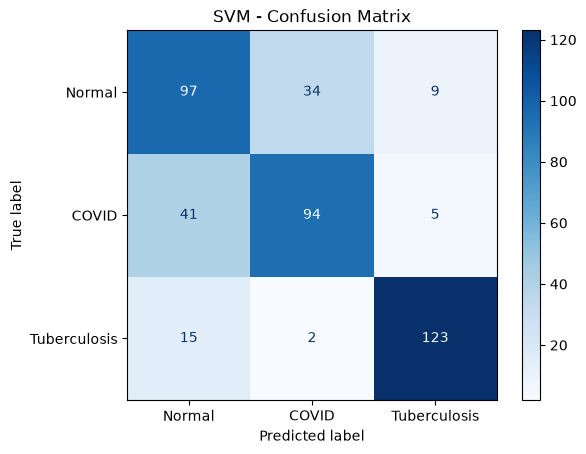

In [52]:
evaluate_model(
    "SVM",
    svm,
    X_test_scaled,
    y_test
)